In [100]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_semi_sticky_wages_data import ModelClass, constraints

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint

from IPython.display import display, Math

from plots import plot_series

model = ModelClass()

par = model.par
sol = model.sol
sim = model.sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This model is used to find a certain condition. Currently, I just minimize the change in average wage level, because it was not easy to get by just setting parameters.

ValueError: the number of columns changed from 1 to 2 at row 2; use `usecols` to select a subset and avoid this error

In [ ]:
param_spec = {
    "phi":   {"value": par.phi,  "bounds": (0.01, 0.99),  "active": True},
    "alpha":    {"value": par.alpha,  "bounds": (0.01, 0.99),  "active": True},
    "mu":     {"value": par.mu,  "bounds": (1.0, 10.0), "active": True},
    "c":        {"value": par.c,  "bounds": (0.1, 1000.0),  "active": True},
}


active_names = [k for k, v in param_spec.items() if v["active"]]
x0 = np.array([param_spec[k]["value"] for k in active_names], dtype=float)
bounds = [param_spec[k]["bounds"] for k in active_names]

def apply_params(par, names, values):
    for name, val in zip(names, values):
        setattr(par, name, float(val))
    return par

def objective(x):
    # Initialize all non-active parameters to their default values
    model.setup()

    for name, spec in param_spec.items():
        if not spec["active"]:
            setattr(par, name, spec["value"])

    apply_params(par, active_names, x)

    model.solve(do_print=False)

    if not constraints(par, model.sol, t=0, do_print=False):
        return 1e12

    model.simulate_transition()

    wage_gap_sim = (
        np.average(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::], axis=1)
        - np.average(model.sim.avg_wage[:, :5] / model.sim.avg_wage[0, :5], axis=1)
    ) * 100

    wage_gap_data = np.loadtxt('Exogenous_estimation/wage_gap_data_mock.csv', delimiter=',')[1:]

    SSE = np.sum((wage_gap_sim - wage_gap_data)**2)

    # print(x, SSE)

    return SSE


def optimize_and_plot(single_run=True, optimizer_trials=2):
    runs = []

    n_runs = 1 if single_run else optimizer_trials

    for i in range(n_runs):
        x0_random = np.array([np.random.uniform(low, high) for (low, high) in bounds], dtype=float)

        result = minimize(
            objective,
            x0=x0_random,
            bounds=bounds,
            method="Nelder-Mead",
            options={'maxiter': 20000, 'disp': False}
        )

        runs.append(result)

        print(list(result.x), result.fun)

    model.setup()

    result = min(runs, key=lambda r: r.fun)

    optimized_values = result.x
    apply_params(par, active_names, optimized_values)

    print("Success:", result.success)
    print("Message:", result.message)
    print("Objective value:", result.fun)
    print("Optimized parameters:")
    for name in active_names:
        print("par." + name + " = ", getattr(par, name))

    
    model.solve()
    model.simulate_transition()

    wage_gap = (
        np.average(model.sim.avg_wage[:, -5::] / model.sim.avg_wage[0, -5::], axis=1)
        - np.average(model.sim.avg_wage[:, :5] / model.sim.avg_wage[0, :5], axis=1)
    ) * 100

    plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")

    return runs, optimized_values

runs, optimized_values = optimize_and_plot(single_run=False, optimizer_trials=100)

[0.9899999999999962, 0.01, 10.0, 1000.0] 5365.0164034367535
[0.6272191553627477, 0.01, 10.0, 781.39880844234] 7279.157013171602
[0.9852522251610525, 0.05699708165709748, 10.0, 221.09487846737227] 3344.2459765954154
[0.6377587089524226, 0.010000000000144699, 4.624682255857765, 292.6557612522611] 7376.9455758777685


par.phi =  0.99
par.alpha =  0.01
par.mu =  10.0
par.c =  213.23283018919219
4350.129107312227


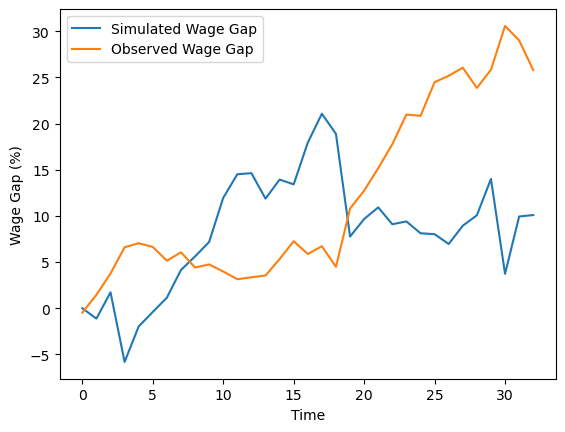

In [111]:
model.setup()

optimized_values = optimized_values

apply_params(par, active_names, optimized_values)

for name in active_names:
    print("par." + name + " = ", getattr(par, name))

model.solve()
model.simulate_transition()

wage_gap = (
    np.average(model.sim.avg_wage[:, -1::] / model.sim.avg_wage[0, -1::], axis=1)
    - np.average(model.sim.avg_wage[:, :1] / model.sim.avg_wage[0, :1], axis=1)
) * 100

data = np.loadtxt('Exogenous_estimation/wage_gap_data_mock.csv', delimiter=',')[1:]

print(np.sum((wage_gap - data)**2))

plt.plot(wage_gap, label='Simulated Wage Gap')
plt.plot(data, label='Observed Wage Gap')
plt.xlabel('Time')
plt.ylabel('Wage Gap (%)')
plt.legend()
plt.show()

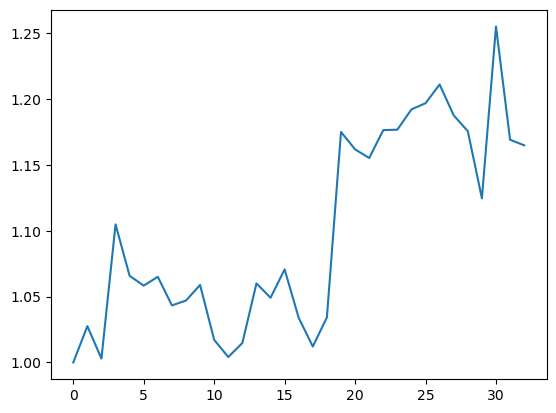

In [43]:
plt.plot(model.sim.avg_wage[:, :1] / model.sim.avg_wage[0, :1])

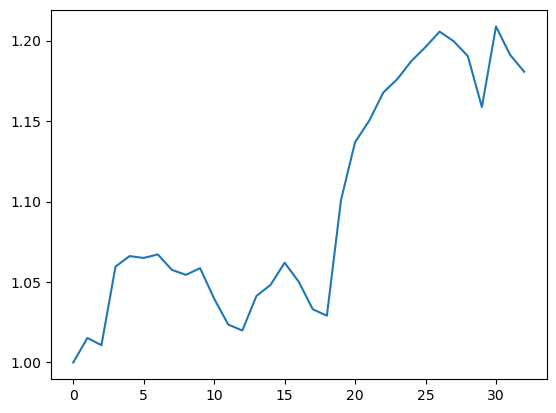

In [44]:
plt.plot(model.sim.avg_wage[:, -1::] / model.sim.avg_wage[0, -1::])

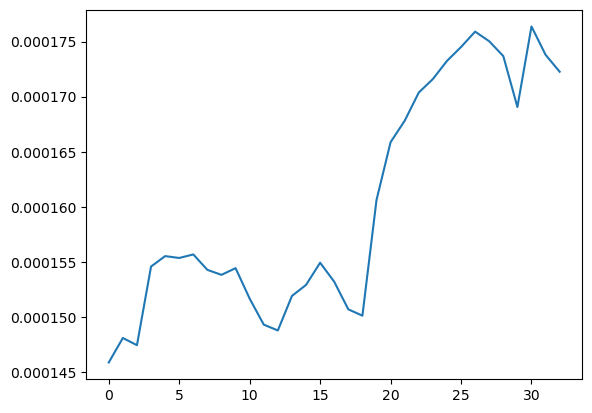

In [45]:
plt.plot(model.sim.avg_wage[:, -1])

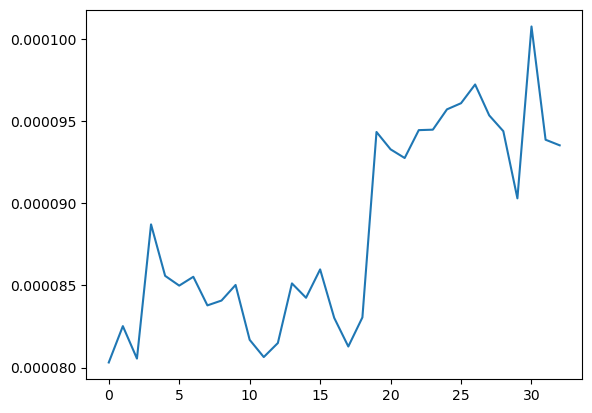

In [46]:
plt.plot(model.sim.avg_wage[:, 0])

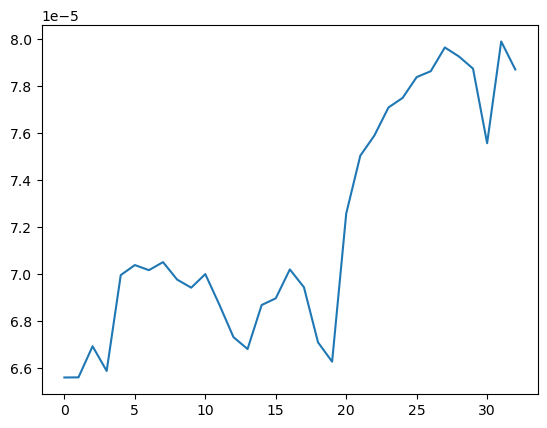

In [37]:
plt.plot(model.sim.avg_wage[:, -1] - model.sim.avg_wage[:, 0], label='Simulated Wage Gap')

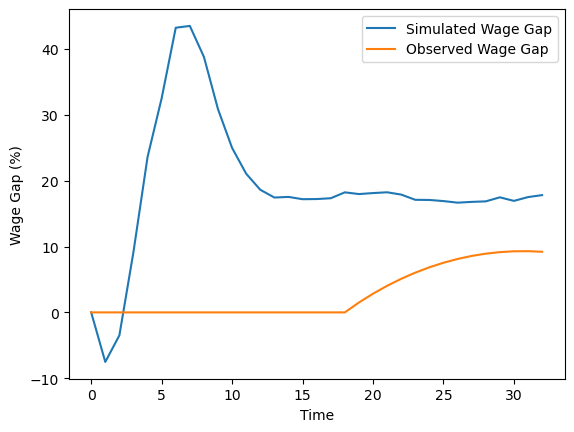